In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from mpl_toolkits.mplot3d import Axes3D
from SpectralPolynomial import ( BASE_POLYS,spectral_correction,Chebyshev)
from PoissonFunctions import eigs_1d_poisson, build_1d_poisson, eigs_2d_poisson, build_2d_poisson
from SpectralQSVT import QSVT,SpectralQSVT

## Base polynomial and error

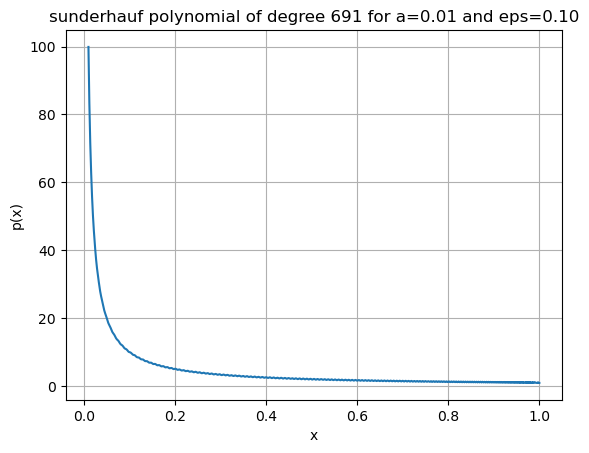

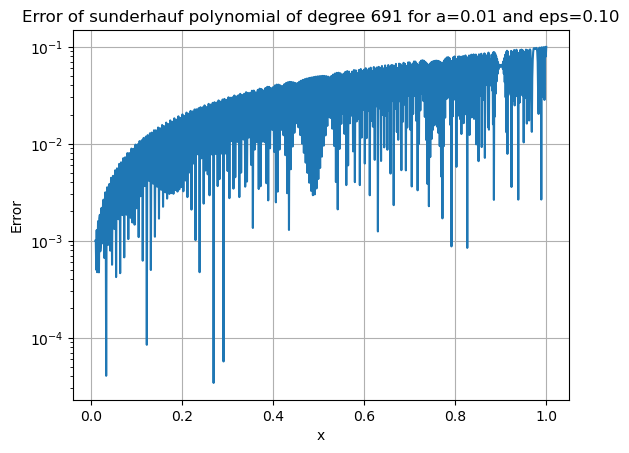

In [2]:
kappa = 100
eps = 0.1
a = 1/kappa
base = 'sunderhauf'
polyClass = BASE_POLYS[base.lower()]

degree   = polyClass.mindegree(eps, a)
poly = polyClass.poly(degree, a)

x = np.linspace(a, 1.0,1000)
y = poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'{base} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of {base} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## spectral Polynomial 

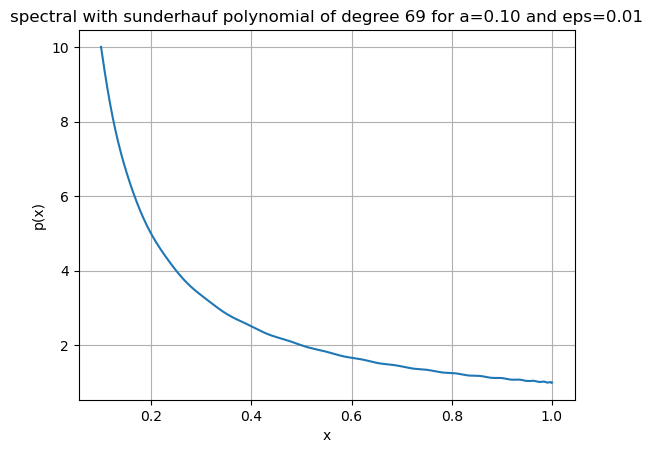

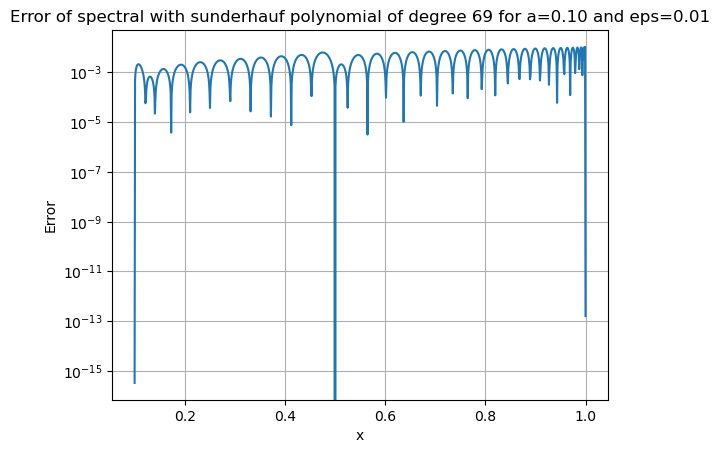

In [3]:
kappa = 10
eps = 0.01
K = 3
lam = np.array([1/kappa, 0.5, 1])
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
polyClass = BASE_POLYS[basePolynomial.lower()]

degree   = polyClass.mindegree(eps, 1/kappa)
poly = polyClass.poly(degree, 1/kappa)

corr = spectral_correction(poly,lam)
coef_H       = poly.coef.copy()
coef_H[1::2] += corr
spectral_poly = Chebyshev(coef_H)


x = np.union1d(np.linspace(1/kappa, 1.0, 1000), lam)
y = spectral_poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'spectral with {basePolynomial} polynomial of degree {degree} for a={1/kappa:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * spectral_poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of spectral with {basePolynomial} polynomial of degree {degree} for a={1/kappa:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## 1D Poisson spectral Correction

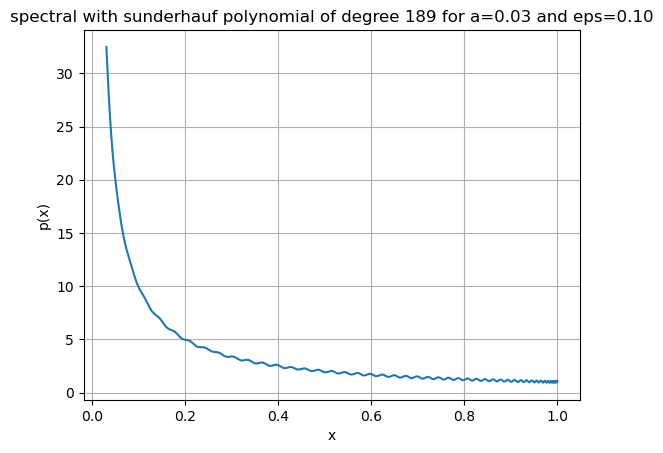

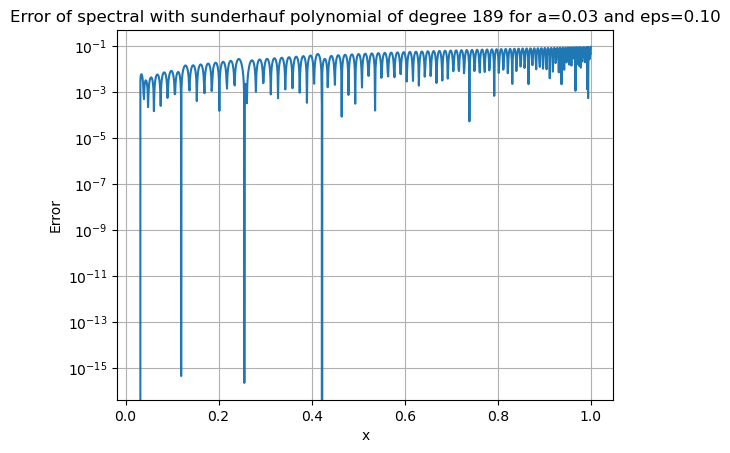

In [4]:
eps = 0.1
m = 3
all_lam  = eigs_1d_poisson(m)
all_lam = all_lam / (1.01*np.max(all_lam))  # Scale eigenvalues to have max < 1
kappa = 1/np.min(all_lam)
a = 1/kappa
N = m**2
K = int(N/2)
lam = all_lam[:K]

a = 1/kappa
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
polyClass = BASE_POLYS[basePolynomial.lower()]

degree   = polyClass.mindegree(eps, a)
poly = polyClass.poly(degree, a)

corr = spectral_correction(poly,lam)
coef_H       = poly.coef.copy()
coef_H[1::2] += corr
spectral_poly = Chebyshev(coef_H)


x = np.union1d(np.linspace(a, 1.0, 1000), lam)
y = spectral_poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'spectral with {basePolynomial} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * spectral_poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of spectral with {basePolynomial} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## 1D Poisson QSVT; base vs spectral polynomial

Condition number kappa=32.485071852301616
Generated 88 phase angles for degree 87
Circuit width: 8, depth: 177
Running statevector simulation...
Success probability: 0.9282105716630231
Norm of real solution: 0.9352121344260098
Fidelity:            0.9998385582492154
Generated 88 phase angles for degree 87
Circuit width: 8, depth: 177
Running statevector simulation...


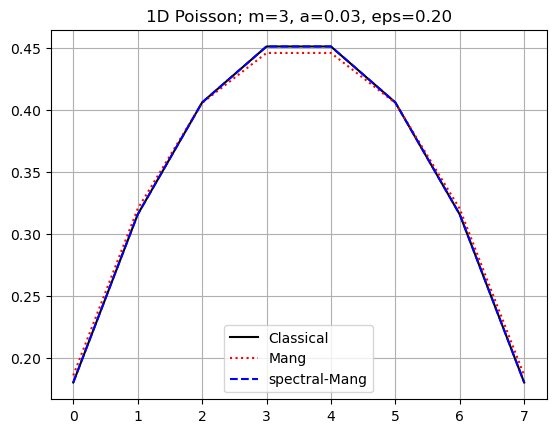

In [5]:
m = 3
eps = 0.2
basePolynomial ='Mang'
A,b  = build_1d_poisson(m, function_type="uniform")
lam = eigs_1d_poisson(m)
A = A / (1.01*np.max(lam))  # Scale to have max singular value < 1
lam = lam / (1.01*np.max(lam))  # Scale eigenvalues accordingly
kappa = 1 / np.min(lam)
print(f"Condition number kappa={kappa}")
# Classical Verification
u_classical = np.linalg.solve(A, b)
u_classical = u_classical / np.linalg.norm(u_classical)


solver_base = QSVT(A, b, kappa, target_error=eps, polyMethod=basePolynomial)
u_base, success_prob, norm_real = solver_base.solve()
print("Success probability:", success_prob)
print("Norm of real solution:", norm_real)
print("Fidelity:           ", np.abs(np.dot(u_base.conj(), u_classical))**2)

solver_spectral = SpectralQSVT(A, b, lam_K=lam, kappa=kappa,
                           target_error=eps, polyMethod=basePolynomial)
u_spectral, success_prob, norm_real = solver_spectral.solve()

plt.plot(u_classical, 'k') 
plt.plot(u_base, 'r:')
plt.plot(u_spectral, 'b--')
plt.legend(['Classical', basePolynomial, 'spectral-'+basePolynomial])
plt.grid()
plt.title(f'1D Poisson; m={m}, a={a:.2f}, eps={eps:.2f}')
plt.show()

## 2D Poisson; base vs spectral

Condition number kappa=117.62580349326262
Generated 306 phase angles for degree 305
Circuit width: 18, depth: 613
Running statevector simulation...
Max of classical solution:  0.10443012810294391
Mang
Success probability: 0.7967900572797777
Norm of real solution: 0.8478300611533713
Max value of solution:  0.1033008969121061
Fidelity:            0.9998685828600645
Generated 286 phase angles for degree 285
Circuit width: 18, depth: 573
Running statevector simulation...
Mang spectral
Success probability: 0.8365842588906627
Norm of real solution: 0.8492277954168207
Max value of solution:  0.10687496691678174
Fidelity:            0.9998119921948256


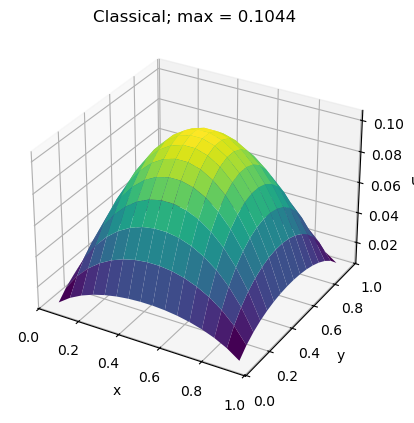

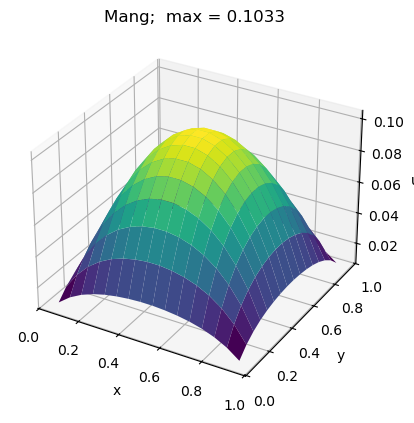

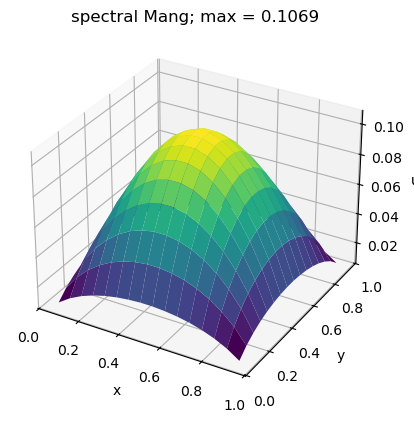

In [6]:
m = 4
eps = 0.2
N = 2**m
K = 1
basePolynomial ='Mang'
A,b  = build_2d_poisson(m, function_type="uniform")
lam = eigs_2d_poisson(m)
A = A / (1.01*np.max(lam))  # Scale to have max singular value < 1
lam = lam / (1.01*np.max(lam))  # Scale eigenvalues accordingly
kappa = 1 / np.min(lam)
print(f"Condition number kappa={kappa}")
# Classical Verification
u_classical = np.linalg.solve(A, b)
u_classical = u_classical / np.linalg.norm(u_classical)


solver_base = QSVT(A, b, kappa, target_error=eps, polyMethod=basePolynomial)
u_base, success_prob, norm_real = solver_base.solve()
print("Max of classical solution: ", np.max(u_classical))
print(50*"=")
print(basePolynomial)
print("Success probability:", success_prob)
print("Norm of real solution:", norm_real)
print("Max value of solution: ", np.max(u_base))
print("Fidelity:           ", np.abs(np.dot(u_base.conj(), u_classical))**2)

degree_override = 285
solver_spectral = SpectralQSVT(A, b, lam_K=lam[:K], kappa=kappa,
                           target_error=eps, degree_override=degree_override, polyMethod=basePolynomial)
u_spectral, success_prob, norm_real = solver_spectral.solve()
print(50*"=")
print(basePolynomial + " spectral")
print("Success probability:", success_prob)
print("Norm of real solution:", norm_real)
print("Max value of solution: ", np.max(u_spectral))
print("Fidelity:           ", np.abs(np.dot(u_spectral.conj(), u_classical))**2)
# plot u_classical, u_base, u_spectral as 3D surfaces in 3 seperate. Show max value in ttitle
N1 = 2**m
h  = 1.0 / (N1 + 1)
x  = np.linspace(h, 1 - h, N1)
X, Y = np.meshgrid(x, x)
ZClassical = u_classical.reshape((N1, N1))
ZBase      = u_base.reshape((N1, N1))
Zspectral    = u_spectral.reshape((N1, N1))

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, ZClassical, cmap='viridis', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
ax.set_title('Classical; max = {:.4f}'.format(np.max(ZClassical)))
plt.show()

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, ZBase, cmap='viridis', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
ax.set_title(basePolynomial + ';  max = {:.4f}'.format(np.max(ZBase)))
plt.show()

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Zspectral, cmap='viridis', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
ax.set_title('spectral ' + basePolynomial + '; max = {:.4f}'.format(np.max(Zspectral)))
plt.show()